<a href="https://colab.research.google.com/github/solivagvs/st554hw06/blob/main/stat554hw06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Bryan Sandor

Course: Stat 554

Title: Homework 6

# Part I - More Practice Querying a Database

## Question 1

First we read in the database.

In [ ]:
import pandas as pd
import sqlite3


# in-memory (local) database
con = sqlite3.connect("lahman_1871-2022.sqlite")

#create a 'cursor' object from our connection
cursor = con.cursor()

#SQL query to return all table names in the data base
#The * indicates we want to select everything
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''

#execute the SQL query on the database!
cursor.execute(get_schema)

# read the table in as a dataframe and view it
baseball = pd.read_sql(get_schema, con)
baseball

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


## Question 2

Now we construct a new table of hall of fame pitchers giving the `playerID` and the sum of the `GS`, `G`, `W`, `L`, `IPOuts`, `CG`, `SHO`, and `SV` columns.

In [ ]:
q2query = '''
    CREATE TABLE IF NOT EXISTS "hallOfFame1" AS
    SELECT hall.playerID,
        SUM(GS), SUM(G), SUM(W), SUM(L), SUM(IPOuts),
        SUM(CG), SUM(SHO), SUM(SV)
    FROM "HallOfFame" AS hall
    INNER JOIN Pitching AS pitch
    ON hall.playerID = pitch.playerID
    GROUP BY hall.playerID
        '''

q2query2 = '''
    SELECT *
    FROM "HallOfFame1"
    '''

#execute the SQL query on the database!
cursor.execute(q2query)
cursor.execute(q2query2)

# read the table in as a dataframe and view it
hallOfFame = pd.read_sql(q2query2, con)
hallOfFame

,playerID,SUM(GS),SUM(G),SUM(W),SUM(L),SUM(IPOuts),SUM(CG),SUM(SHO),SUM(SV)
0,abbotji01,254,263,87,108,5022,31,6,0
1,adamsba01,5325,7230,2910,2100,134790,3090,660,225
2,aguilri01,89,732,86,81,3874,10,0,318
3,akerja01,0,495,47,45,2238,0,0,123
4,alexado01,464,561,194,174,10103,98,18,3
...,...,...,...,...,...,...,...,...,...
522,zachrpa01,154,293,69,67,3532,29,7,3
523,zahnge01,270,304,111,109,5547,79,20,1
524,zambrca01,302,354,132,91,5877,10,5,0
525,zeileto01,0,2,0,0,6,0,0,0


## Question 3

Next, for all the hall of fame pitchers, we create another new table of all their batting statistics, viz., the sum of their `AB`, `R`, `H`, `HR`, `RBI`, `BB`, `SO`.

In [ ]:
q3query = '''
    CREATE TABLE IF NOT EXISTS "hallOfFame2" AS
    SELECT hall.playerID,
    SUM(bat.AB), SUM(bat.R), SUM(bat.H), SUM(bat.HR), SUM(bat.RBI),
    SUM(bat.BB), SUM(bat.SO)
    FROM "HallOfFame" AS hall
    INNER JOIN Pitching AS pitch
    ON hall.playerID = pitch.playerID
    INNER JOIN Batting AS bat
    ON bat.playerID = pitch.playerID
    GROUP BY hall.playerID
        '''

q3query2 = '''
    SELECT *
    FROM "HallOfFame2"
    '''

#execute the SQL query on the database!
cursor.execute(q3query)
cursor.execute(q3query2)

# read the table in as a dataframe and view it
hallOfFame2 = pd.read_sql(q3query2, con)
hallOfFame2

,playerID,SUM(bat.AB),SUM(bat.R),SUM(bat.H),SUM(bat.HR),SUM(bat.RBI),SUM(bat.BB),SUM(bat.SO)
0,abbotji01,231,0,22,0,33.0,0,110.0
1,adamsba01,290415,22515,61560,855,21375.0,15105,55290.0
2,aguilri01,2641,228,532,57,209.0,114,703.0
3,akerja01,1288,42,98,0,56.0,14,714.0
4,alexado01,6095,437,1012,0,391.0,207,1771.0
...,...,...,...,...,...,...,...,...
522,zachrpa01,3498,99,396,0,66.0,154,1408.0
523,zahnge01,602,42,84,0,14.0,0,126.0
524,zambrca01,8316,900,1980,288,852.0,120,2880.0
525,zeileto01,15146,1972,4008,506,2220.0,1890,2558.0


## Question 4

Finally, we join the previous two results into a single table.

In [ ]:
q4query = '''
    CREATE TABLE IF NOT EXISTS "hallOfFameFinal" AS
    SELECT *
    FROM hallOfFame1 AS hall1
    INNER JOIN hallOfFame2 AS hall2
    ON hall1.playerID = hall2.playerID
    GROUP BY hall1.playerID
    '''

#q4query2 = '''
    #ALTER TABLE "hallOfFameFinal"
    #DROP COLUMN "playerID:1"
    #'''

q4query3 = '''
    SELECT *
    FROM "hallOfFameFinal"
    '''

#execute the SQL query on the database!
cursor.execute(q4query)
#cursor.execute(q4query2)
cursor.execute(q4query3)

# read the table in as a dataframe and view it
hallOfFameFinal = pd.read_sql(q4query3, con)
hallOfFameFinal

,playerID,SUM(GS),SUM(G),SUM(W),SUM(L),SUM(IPOuts),SUM(CG),SUM(SHO),SUM(SV),playerID:1,SUM(bat.AB),SUM(bat.R),SUM(bat.H),SUM(bat.HR),SUM(bat.RBI),SUM(bat.BB),SUM(bat.SO)
0,abbotji01,254,263,87,108,5022,31,6,0,abbotji01,231,0,22,0,33.0,0,110.0
1,adamsba01,5325,7230,2910,2100,134790,3090,660,225,adamsba01,290415,22515,61560,855,21375.0,15105,55290.0
2,aguilri01,89,732,86,81,3874,10,0,318,aguilri01,2641,228,532,57,209.0,114,703.0
3,akerja01,0,495,47,45,2238,0,0,123,akerja01,1288,42,98,0,56.0,14,714.0
4,alexado01,464,561,194,174,10103,98,18,3,alexado01,6095,437,1012,0,391.0,207,1771.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,zachrpa01,154,293,69,67,3532,29,7,3,zachrpa01,3498,99,396,0,66.0,154,1408.0
523,zahnge01,270,304,111,109,5547,79,20,1,zahnge01,602,42,84,0,14.0,0,126.0
524,zambrca01,302,354,132,91,5877,10,5,0,zambrca01,8316,900,1980,288,852.0,120,2880.0
525,zeileto01,0,2,0,0,6,0,0,0,zeileto01,15146,1972,4008,506,2220.0,1890,2558.0


# Part II - Messing with Classes

*Note*: I had issues staying connected with the JupiterLab over VPN so I used Google Colab instead.

We begin by crafting a class with the appropriate designations.

In [ ]:
# NAME:  BRYAN SANDOR
# CLASS: ST 554
# TITLE: HOMEWORK 06

class SLR_slope_simulator:
    """ Repeatedly do simulations around the estimate of a sample slope """

    # include relevant packages
    import numpy as np
    from numpy.random import default_rng

    def __init__(self, beta_0, beta_1, x, sigma, seed):
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma
        self.x = x
        self.n = len(x)
        self.seed = seed
        self.slopes = []
        self.y = []
        self.rng = np.random.default_rng(self.seed)

    def generate_data(self):
        #create the 'responses' modeled from the line plus a random deviation
        self.y = self.beta_0 + self.beta_1 * x + \
            self.rng.normal(scale = self.sigma, size = self.n)
        return x, self.y

    def fit_slope(self):
        # Can't figure out why I have to import this directly in this method
        # when the initial imports all seemed to be inherited within this class
        from sklearn import linear_model

        #prepare for the LR fit
        reg = linear_model.LinearRegression()
        #Create a reg object

        #find the least squares solution and store it
        fit = reg.fit(x.reshape(-1, 1), self.y)

        #print the result
        #print(f"The slope is estimated as {round(fit.coef_[0], 4)}")
        return fit.coef_[0]

    def run_simulations(self, iterations):
        for i in range(iterations):
        #create the 'responses' modeled from the line plus a random deviation
            self.generate_data()

        #find the least squares solutions and store them
            self.slopes.append(self.fit_slope())

        self.slopes = np.array(self.slopes)
        return

    def plot_sampling_distribution(self):
        import matplotlib.pyplot as plt

        if len(self.slopes) == 0:
            print("Please run the run_simulations() method, first.")
        else:
            #visualize the distribution of the slopedata
            plt.hist(self.slopes)
            plt.show()
        return

    def find_prob(self, value, sided:str):
        if sided == "above":
            #estimate the probability we are larger than value
            bool_prob = self.slopes > value
            print(round(bool_prob.mean(), 4))
        elif sided == "below":
            # estimate the probability we are smaller than value
            bool_prob = self.slopes < value
            print(round(bool_prob.mean(), 4))
        elif sided == "two-sided":
            # estimate the probability we are at least as extreme as value
            if value > np.median(self.slopes):
                bool_prob = self.slopes > value
                print(2 * round(bool_prob.mean(), 4))
            else:
                bool_prob = self.slopes < value
                print(2 * round(bool_prob.mean(), 4))
        else:
            print("Please indicate 'above', 'below', or 'two-sided'")
        return

We create object using the class, called `test`.

In [ ]:
import numpy as np
from numpy.random import default_rng

x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)

test = SLR_slope_simulator(beta_0 = 12, beta_1 = 2, x = x, sigma = 1, seed = 10)

We check to ensure an error message prints if the list is empty.

In [ ]:
test.plot_sampling_distribution()

Please run the run_simulations() method, first.


Then we generate a list of 10000 slopes.

In [ ]:
test.run_simulations(10000)

And plot their frequencies in a histogram.

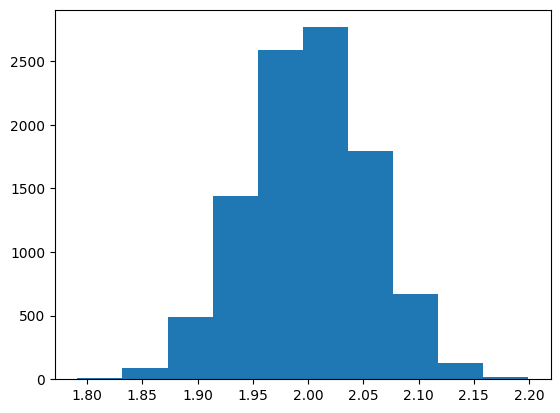

In [ ]:
test.plot_sampling_distribution()

Then we check the probability function.

In [ ]:
test.find_prob(2.1, "two-sided")

0.0704


Finally, we look at the first and last few values for the slopes.

In [ ]:
test.slopes

array([2.0239168 , 1.99560551, 2.04249093, ..., 1.93451109, 2.01445559,
       2.07173587])